In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from joblib import Parallel, delayed  # FOR PARALLEL WORKS

# 1.DECIMALES EN TABLA (2) Y EVITA LA NOTACION CIENTIFICA
# 2.CANTIDAD DE COLUMNAS POR TABLA
pd.options.display.float_format='{:20.2f}'.format
pd.set_option('display.max_columns',500)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [6]:
df=pd.read_excel('x10.xlsx')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


stop-service-name-dosvc
set-service-nameDosvc-startuptypedisable

In [9]:
x1=df.isna().sum()[df.isna().sum()>0].sort_values()
x2=df.isna().sum()[df.isna().sum()>0].sort_values()*100/len(df)
print(f'{x1}\n',f'\n{x2}')

Description      2928
Customer ID    107927
dtype: int64
 
Description                   0.56
Customer ID                  20.54
dtype: float64


In [10]:
df.iloc[(df['Quantity']<0).values].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


In [11]:
df['Invoice']=df['Invoice'].astype('str')
# FILTRED VALUES WITH A SPECIFIC LENGHT, 6 IN THIS CASE
df[df['Invoice'].str.match('^\\d{6}$')==False].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


In [12]:
# ELIMINATE NUMBERS IN THE VALUES
df['Invoice'].str.replace('[0-9]','',regex=True).unique()

<StringArray>
['', 'C', 'A']
Length: 3, dtype: str

In [13]:
# FILTERS THE VALUES WITH A SPECIFIC CHARACTER AT THE BEGINING
df.iloc[(df['Invoice'].str.startswith('A')).values].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [14]:
# FILTER LENGHT OF COLUMNS BY VALUES
df['StockCode']=df['StockCode'].astype('str')
df[(df['StockCode'].str.match('^\\d{5}$')==False)&(df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')==False)]\
    ['StockCode'].head().unique()

<StringArray>
['POST', 'D']
Length: 2, dtype: str

In [15]:
# FILTER BY WORDS
df[df['StockCode'].str.contains('^DOT')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


CLEANING DATA

In [16]:
cleaned_df=df.copy()

In [17]:
cleaned_df['Invoice']=cleaned_df['Invoice'].astype('str')
mask=(cleaned_df['Invoice'].str.match('^\\d{6}$')==True)
cleaned_df=cleaned_df[mask]
cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [18]:
cleaned_df['StockCode']=cleaned_df['StockCode'].astype('str')
mask=(
(cleaned_df['StockCode'].str.match('^\\d{5}$')==True)\
|(cleaned_df['StockCode'].str.match('^\\d{5}[a-zA-Z]+$')==True)\
|(cleaned_df['StockCode'].str.match('^PSD$')==True)
)
cleaned_df=cleaned_df[mask]
cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [19]:
# DROP COLUMN, BASED IN A SPECIFIC COLUMN. IF THE VALUE EXIST IT SAVED, 
#   ELSE THE ROW IS ELIMINATED ((SUBSET))
cleaned_df.dropna(subset=['Customer ID'],inplace=True)
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406323.00,406323,406323.00,406323.00
mean,13.62,2010-07-01 10:14:46.649094,2.99,15373.66
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [20]:
cleaned_df.iloc[(cleaned_df['Price']==0).values].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.00,16126.00,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.00,15658.00,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.00,14108.00,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.00,15070.00,United Kingdom


In [21]:
len(cleaned_df[cleaned_df['Price']==0])

28

In [22]:
cleaned_df=cleaned_df[cleaned_df['Price']>0]

FEATURE ENGINEERING

In [23]:
cleaned_df['SalesLineTotal']=cleaned_df['Quantity']*cleaned_df['Price']
cleaned_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00


In [24]:
cleaned_df['Customer ID']=cleaned_df['Customer ID'].astype(float).astype(int).astype(str)

In [25]:
a_df=(
    cleaned_df.groupby(by='Customer ID',as_index=False)
    .agg(
        MonetaryValue=('SalesLineTotal','sum'),
        Frequency=('Invoice','nunique'),
        LastInvoiceDate=('InvoiceDate','max')
    )
)
a_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346,169.36,2,2010-06-28 13:53:00
1,12347,1323.32,2,2010-12-07 14:57:00
2,12348,221.16,1,2010-09-27 14:59:00
3,12349,2221.14,2,2010-10-28 08:23:00
4,12351,300.93,1,2010-11-29 15:23:00


In [26]:
max_invoicedate=a_df['LastInvoiceDate'].max()
a_df['Recency']=(max_invoicedate-a_df['LastInvoiceDate']).dt.days
a_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346,169.36,2,2010-06-28 13:53:00,164
1,12347,1323.32,2,2010-12-07 14:57:00,2
2,12348,221.16,1,2010-09-27 14:59:00,73
3,12349,2221.14,2,2010-10-28 08:23:00,42
4,12351,300.93,1,2010-11-29 15:23:00,10


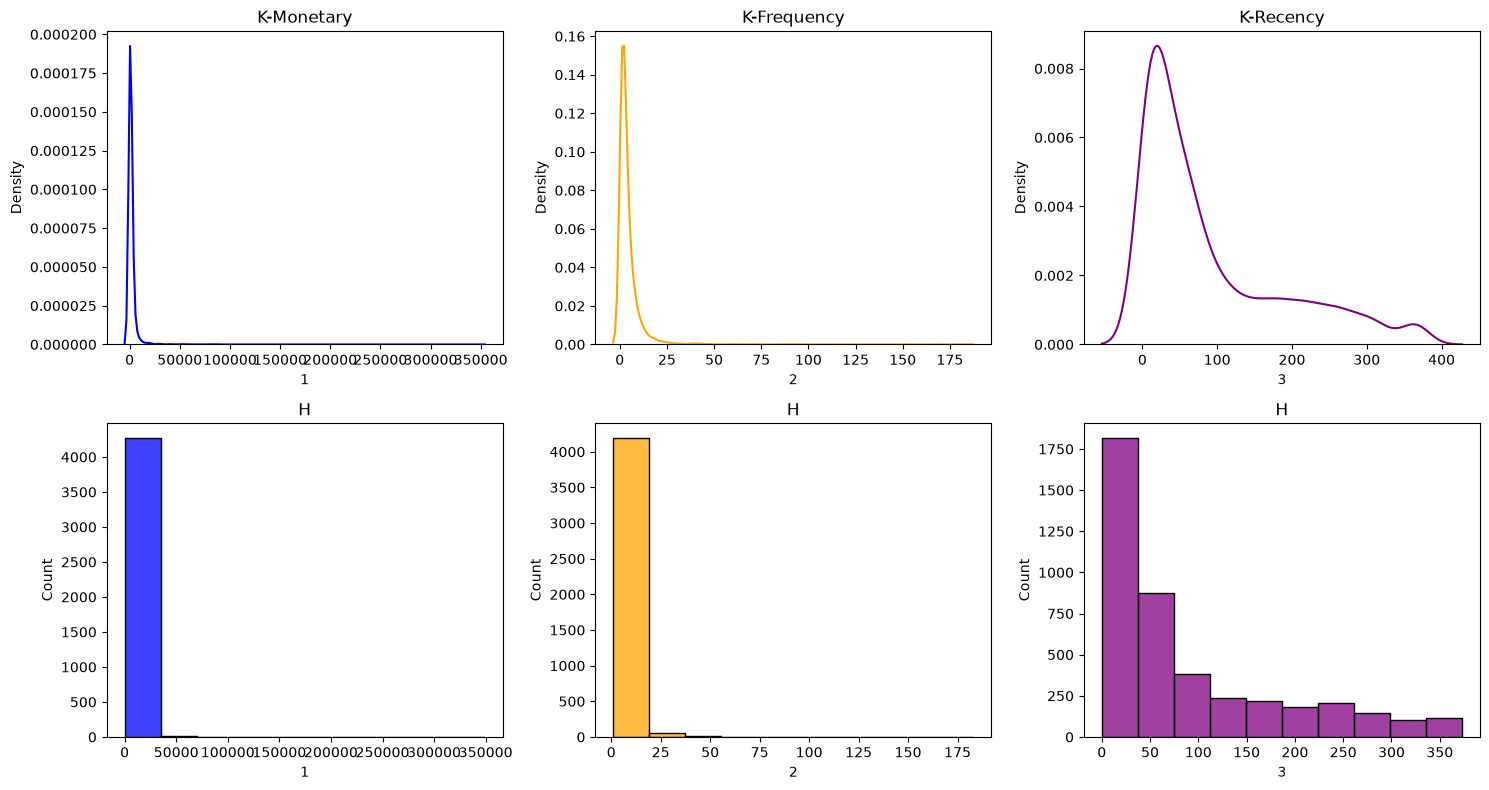

In [27]:
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(15,8))

(
    sns.kdeplot(data=a_df,x='MonetaryValue',ax=axes[0,0],color='blue')
    .set(title='K-Monetary',xlabel='1')
)
(
    sns.kdeplot(data=a_df,x='Frequency',ax=axes[0,1],color='orange')
    .set(title='K-Frequency',xlabel='2')
)
(
    sns.kdeplot(data=a_df,x='Recency',ax=axes[0,2],color='purple')
    .set(title='K-Recency',xlabel='3')
)
(
    sns.histplot(data=a_df,x='MonetaryValue',ax=axes[1,0],color='blue',bins=10)
    .set(title='H',xlabel='1')
)
(
    sns.histplot(data=a_df,x='Frequency',ax=axes[1,1],color='orange',bins=10)
    .set(title='H',xlabel='2')
)
(
    sns.histplot(data=a_df,x='Recency',ax=axes[1,2],color='purple',bins=10)
    .set(title='H',xlabel='3')
)


plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

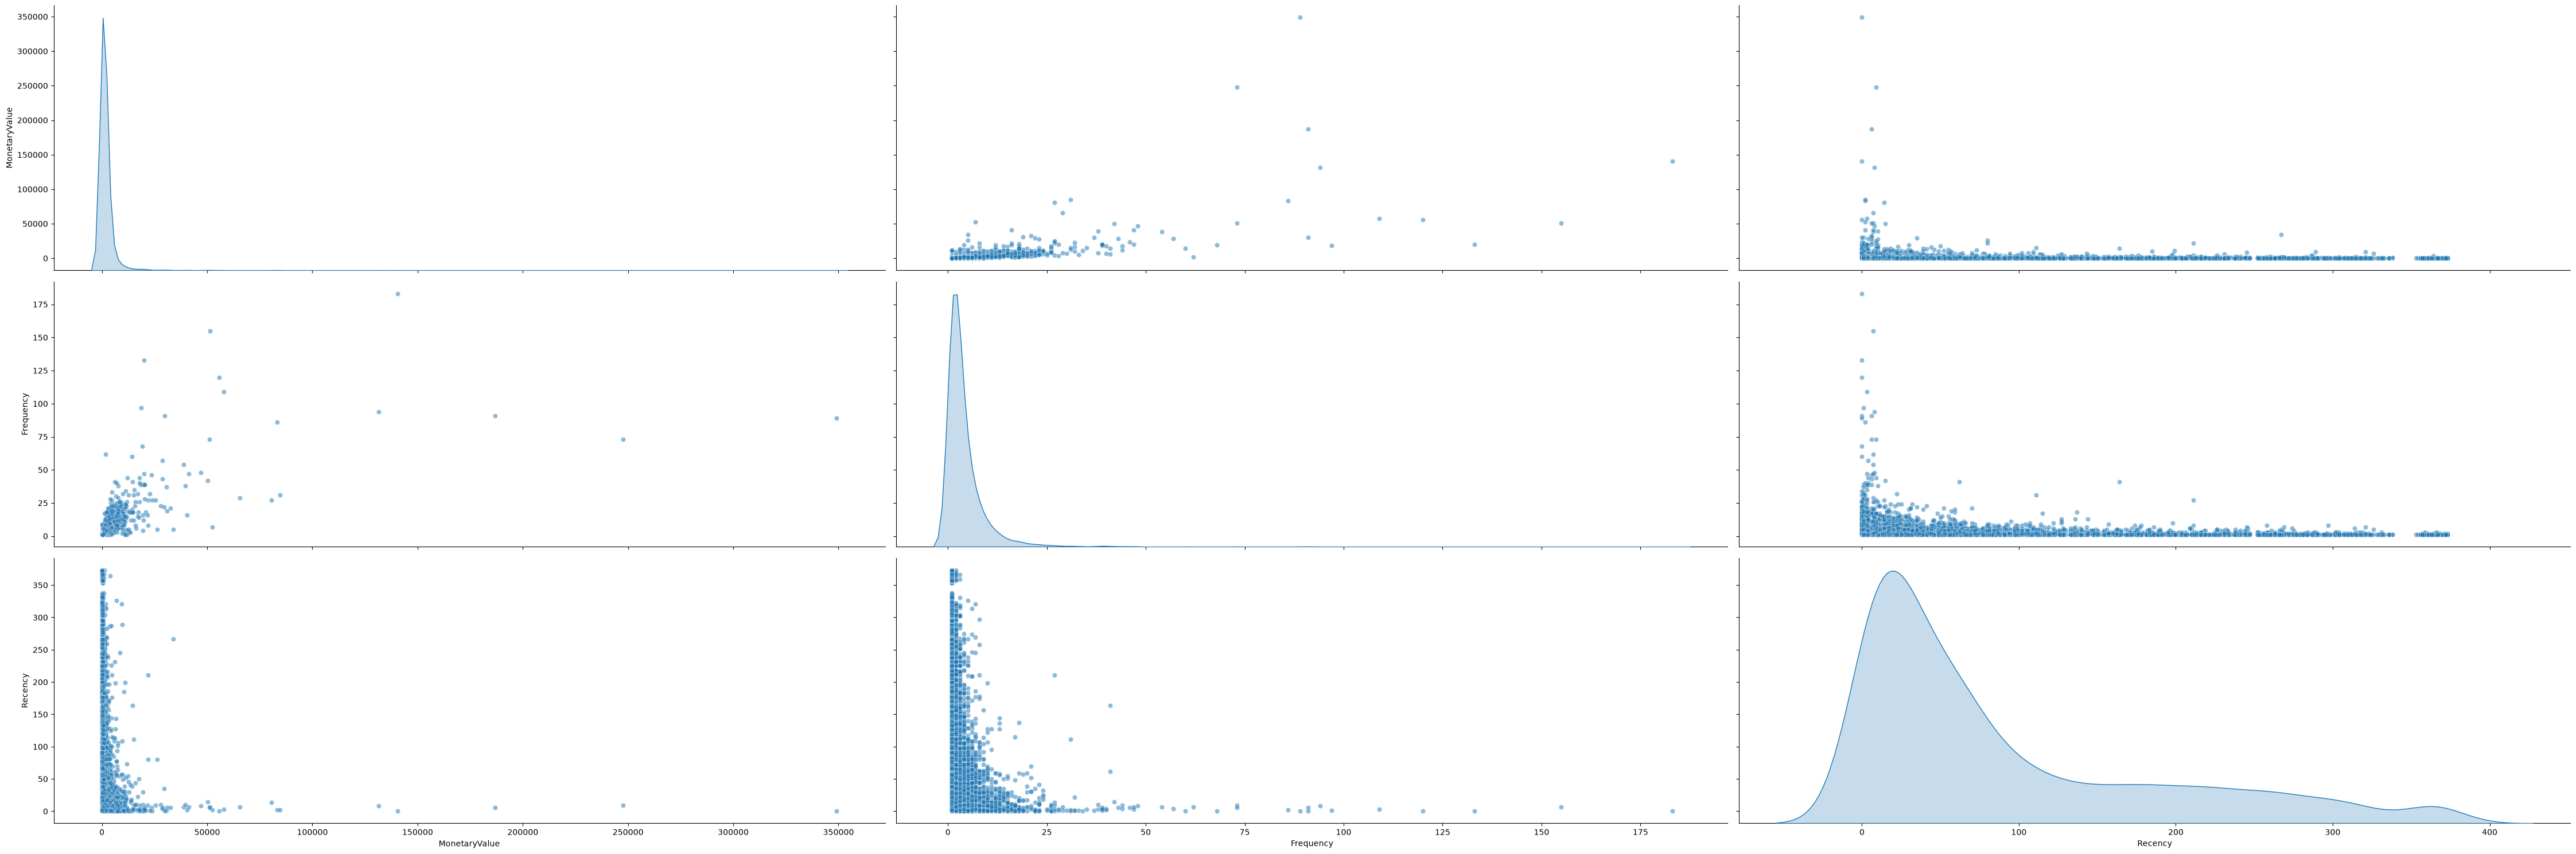

In [28]:
plt.figure(figsize=(10,5))
sns.pairplot(
    a_df,
    kind='scatter',
    vars=['MonetaryValue','Frequency','Recency'],
    plot_kws={'alpha':.5},
    diag_kind='kde',
    height=5,
    aspect=3
)
plt.tight_layout()
plt.show()

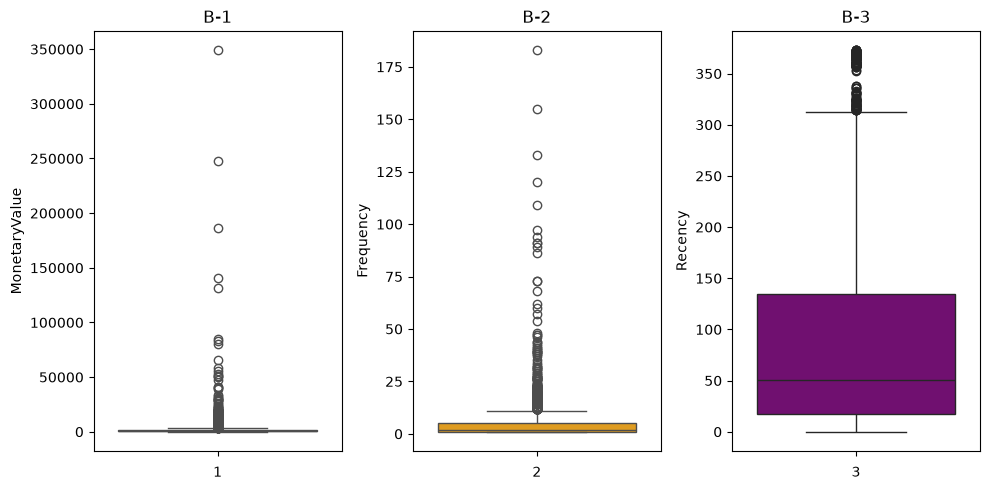

In [29]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(10,5))
(
    sns.boxplot(data=a_df,y='MonetaryValue',ax=axes[0],color='blue')
    .set(title='B-1',xlabel='1')
)
(
    sns.boxplot(data=a_df,y='Frequency',ax=axes[1],color='orange')
    .set(title='B-2',xlabel='2')
)
(
    sns.boxplot(data=a_df,y='Recency',ax=axes[2],color='purple')
    .set(title='B-3',xlabel='3')
)
plt.tight_layout()
plt.show()

In [30]:
m_q1,m_q3=np.nanpercentile(a_df['MonetaryValue'],[25,75])
m_iqr=m_q3-m_q1
ml_l=m_q1-(1.5*m_iqr)
mu_l=m_q3+(1.5*m_iqr)
m_outlier=(a_df['MonetaryValue']<ml_l)|(a_df['MonetaryValue']>mu_l)
mv_outlier=a_df[m_outlier].copy()
mv_outlier.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423,423.00
mean,12188.10,17.17,2010-11-09 12:26:02.978723,30.04
min,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,10273.24,18.00,2010-12-06 10:34:30,31.00
max,349164.35,183.00,2010-12-09 19:32:00,364.00
std,25830.85,19.73,NaN,51.54


In [31]:
f_q1,f_q3=np.nanpercentile(a_df['Frequency'],[25,75])
f_iqr=f_q3-f_q1
fl_l=f_q1-(1.5*f_iqr)
fu_l=f_q3+(1.5*f_iqr)
f_outlier=(a_df['Frequency']<fl_l)|(a_df['Frequency']>fu_l)
fr_outlier=a_df[f_outlier].copy()
fr_outlier.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279,279.00
mean,14409.71,23.81,2010-11-23 11:06:20.645161,16.09
min,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,11692.41,23.00,2010-12-07 11:08:30,19.00
max,349164.35,183.00,2010-12-09 19:32:00,211.00
std,31381.74,21.93,NaN,26.59


In [32]:
non_outliers=a_df[(~a_df.index.isin(mv_outlier.index))&(~a_df.index.isin(fr_outlier.index))]
non_outliers.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809,3809.00
mean,885.50,2.86,2010-09-03 11:16:46.516146,97.08
min,1.55,1.00,2009-12-01 10:49:00,0.00
25%,279.91,1.00,2010-07-08 14:48:00,22.00
50%,588.05,2.00,2010-10-12 16:25:00,58.00
75%,1269.05,4.00,2010-11-17 13:14:00,154.00
max,3788.21,11.00,2010-12-09 20:01:00,373.00
std,817.67,2.24,NaN,98.11


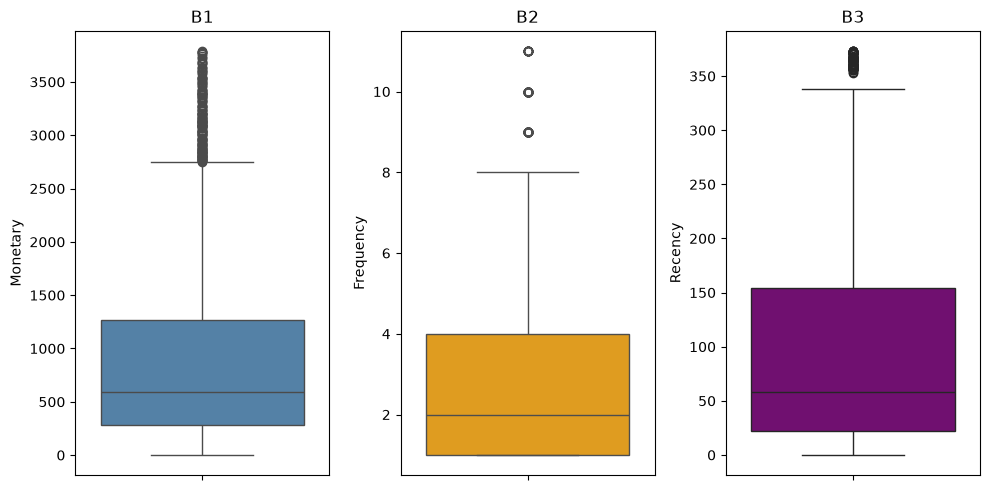

In [33]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(10,5))
(
    sns.boxplot(data=non_outliers,y='MonetaryValue',ax=axes[0],color='steelblue')
    .set(title='B1',ylabel='Monetary')
)
(
    sns.boxplot(data=non_outliers,y='Frequency',ax=axes[1],color='orange')
    .set(title='B2',ylabel='Frequency')
)
(
    sns.boxplot(data=non_outliers,y='Recency',ax=axes[2],color='purple')
    .set(title='B3',ylabel='Recency')
)
plt.tight_layout()
plt.show()

In [34]:
fig = make_subplots(rows=1, cols=3,subplot_titles=('B1','B2','B3'))
fig.add_trace(
    go.Box(y=non_outliers['MonetaryValue'], name="Monetary", marker_color="steelblue")
    ,row=1, col=1
)
fig.add_trace(
    go.Box(y=non_outliers['Frequency'], name="Frequency", marker_color="orange")
    ,row=1, col=2
)
fig.add_trace(
    go.Box(y=non_outliers['Recency'], name="Recency", marker_color="purple")
    ,row=1, col=3
)
fig.update_layout(showlegend=False)
fig.show()

In [35]:
# import plotly.graph_objects as go

# 1. Lienzo en blanco
fig = go.Figure()

# 2. Primera Capa: Gráfico de Barras
fig.add_trace(
    go.Bar(x=['Q1', 'Q2', 'Q3'], y=[100, 150, 120], name='Ventas Reales')
)

# 3. Segunda Capa: Gráfico de Líneas
fig.add_trace(
    go.Scatter(x=['Q1', 'Q2', 'Q3'], y=[110, 130, 140], mode='lines+markers', name='Proyección')
)

# 4. Ajustes estéticos globales
fig.update_layout(
    title='Rendimiento: Ventas vs Proyección',
    xaxis_title='Trimestre',
    yaxis_title='Monto ($)'
)

fig.show()

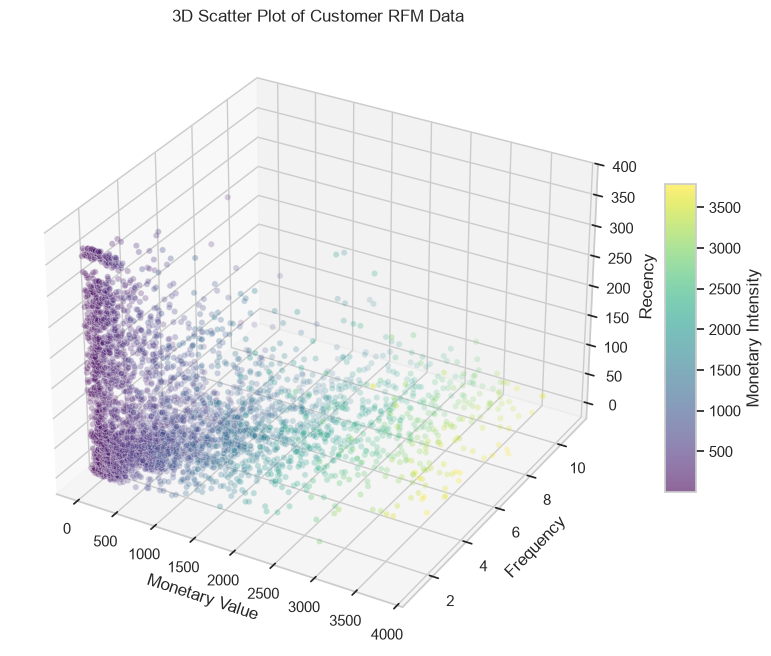

In [36]:
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

# 2. Mejoras: Transparencia (alpha) y Color dinámico (c y cmap)
# Coloreamos los puntos basándonos en el 'MonetaryValue' para resaltar a los mejores clientes
scatter = ax.scatter(
    non_outliers["MonetaryValue"], 
    non_outliers["Frequency"], 
    non_outliers["Recency"],
    c=non_outliers["MonetaryValue"], # El color cambia según el valor monetario
    cmap="viridis",                    # Paleta de colores secuencial
    alpha=0.6,                         # Transparencia del 60% para ver puntos superpuestos
    edgecolor='w',                     # Borde blanco fino alrededor de cada punto
    linewidth=0.5
)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer RFM Data')

# 3. Añadimos una barra de color lateral para entender la escala
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Monetary Intensity')

plt.show()

In [37]:
# PLOTLY-3D
fig = px.scatter_3d(
    non_outliers, 
    x='MonetaryValue',y='Frequency',z='Recency'
    ,size='Frequency',color='MonetaryValue'# color_continuous_scale='teal',# opacity=0.5,
    ,template='plotly_white'
)
fig.update_traces(
    marker=dict(line=dict(width=1, color='DarkSlateGrey'))
)
fig.show()

In [38]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(
    non_outliers[['MonetaryValue','Frequency','Recency']]
)
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.53551441, -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488782,  0.50659348, -0.81634357]], shape=(3809, 3))

In [39]:
scaled_data_df=pd.DataFrame(scaled_data,columns=('MonetaryValue','Frequency','Recency'),index=non_outliers.index)
scaled_data_df.head()

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89


In [74]:
fig=px.scatter_3d(
    scaled_data_df,x='MonetaryValue',y='Frequency',z='Recency'
    # ,size='Frequency'
    ,color='MonetaryValue',color_continuous_scale='teal'
    ,template='plotly_dark'
)
fig.update_traces(marker=dict(line=dict(width=1,color='DarkSlateGrey')))
fig.show()

K-MEAN CLUSTER

In [44]:
k_val=range(2,13)
tot_iter=len(k_val)
inertia=np.zeros(tot_iter)
sil_sco=np.zeros(tot_iter)
data_m=scaled_data_df.values
for idx,k in enumerate(k_val):
    kmeans=KMeans(n_clusters=k,random_state=42,max_iter=1000,n_init=10)
    cluster_lab=kmeans.fit_predict(data_m)
    sil_scores=silhouette_score(data_m,cluster_lab)
    sil_sco[idx]=sil_scores
    inertia[idx]=kmeans.inertia_

In [59]:
fig=make_subplots(rows=1,cols=2,subplot_titles=('inertia','silhouette'))
fig.add_trace(
    go.Scatter(
        x=list(k_values),y=inertia,mode='lines+markers'
        ,name='inertia',marker=dict(color='steelblue',line=dict(width=1))
    )
    ,row=1,col=1
)
fig.add_trace(
    go.Scatter(
        x=list(k_values),y=sil_sco,mode='lines+markers'
        ,name='silhouette',marker=dict(color='orange',line=dict(width=1))
    )
    ,row=1,col=2
)
fig.update_layout(title_text='K-MEANS',template='plotly_dark')
fig.update_xaxes(title_text='clusters',dtick=2)
fig.update_yaxes(title_text='inertia',row=1,col=1)
fig.update_yaxes(title_text='silhouette',row=1,col=2)
fig.show()

In [124]:
df_resultados = pd.DataFrame({'k': list(k_values),'Inercia': inertia,'Silueta': silhouette_scores})
df_tot = df_resultados.melt(id_vars='k',value_vars=['Inercia', 'Silueta']
                              ,var_name='Metrica',value_name='Valor'
                              )
fig = px.line(
    df_tot, x='k',y='Valor', 
    facet_col='Metrica', # Divide el lienzo en columnas basadas en el nombre de la métrica
    color='Metrica',     # Aplica un color distinto a cada línea
    markers=True,template='plotly_dark',
    title='K-MEANS'
)
fig.update_yaxes(matches=None)
fig.for_each_yaxis(lambda yaxis: yaxis.update(title=''))
fig.update_xaxes(dtick=2)
fig.show()

In [114]:
kmeans=KMeans(n_clusters=4,random_state=42,max_iter=1000,n_init=10)
cluster_lab=kmeans.fit_predict(scaled_data_df)
cluster_lab

array([3, 0, 2, ..., 3, 0, 0], shape=(3809,), dtype=int32)

In [115]:
non_outliers['Cluster']=cluster_lab
non_outliers.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,Cluster_str
0,12346,169.36,2,2010-06-28 13:53:00,164,3,0
1,12347,1323.32,2,2010-12-07 14:57:00,2,0,2
2,12348,221.16,1,2010-09-27 14:59:00,73,2,2
3,12349,2221.14,2,2010-10-28 08:23:00,42,0,1
4,12351,300.93,1,2010-11-29 15:23:00,10,2,2


In [92]:
# PALETE OF COLORS TO USE IN PLOTLY
# '#1f77b4'  # Blue
# '#ff7f0e'  # Orange
# '#2ca02c'  # Green
# '#d62728'  # Red

In [116]:
non_outliers['Cluster_str']=non_outliers['Cluster'].astype(str)
cluster_colors={'0':'steelblue','2':'orange','2':'red'}
fig= px.scatter_3d(
    non_outliers,x='MonetaryValue',y='Frequency',z='Recency'
    ,color='Cluster_str',color_discrete_map=cluster_colors
    ,title='customer segmentation'
)
fig.update_layout(template='plotly_dark',legend_title_text='legend')
fig.update_traces(marker=dict(size=3,line=dict(width=.5)))
fig.show()

ANALITICS OF K-MEANS

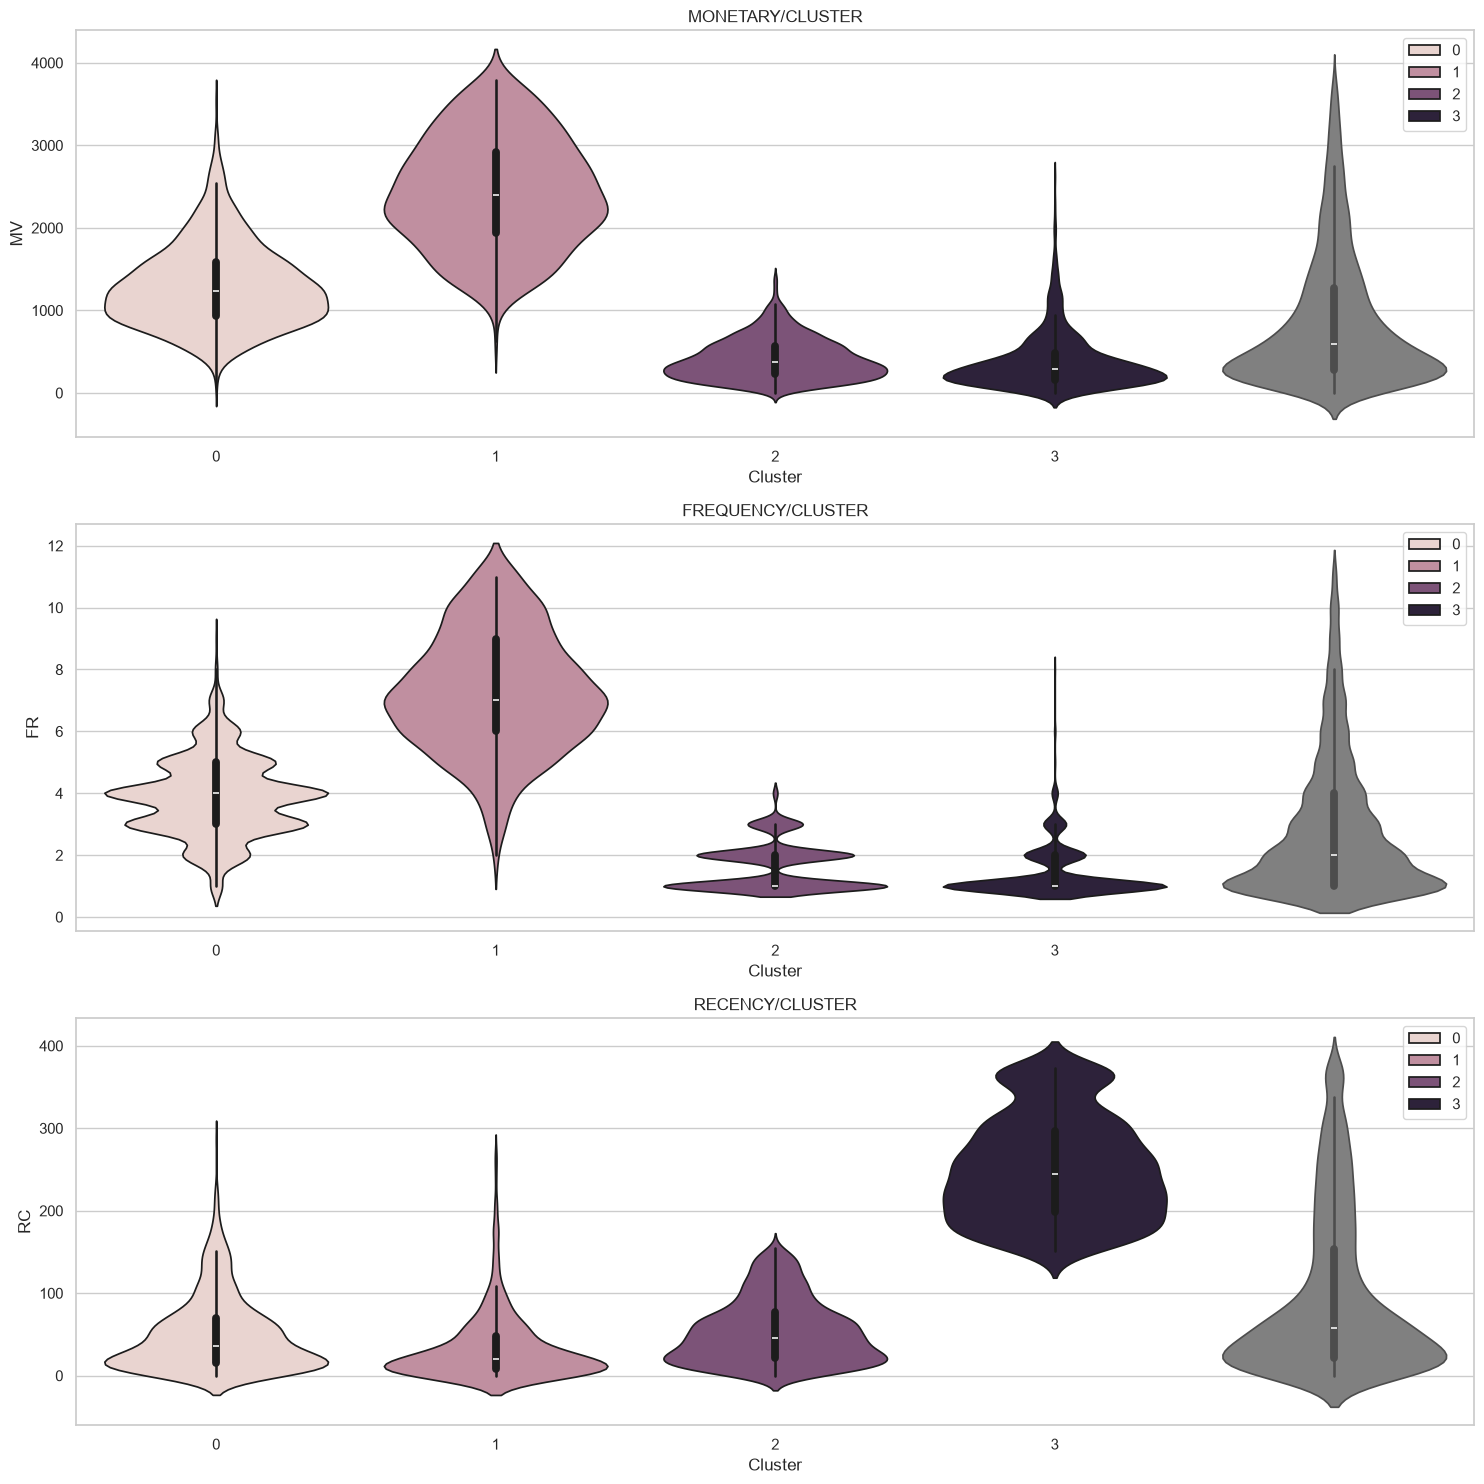

In [151]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 15))
(sns.violinplot(x=non_outliers['Cluster'], y=non_outliers['MonetaryValue']
                , hue=non_outliers['Cluster'], ax=axes[0]))
(sns.violinplot(y=non_outliers['MonetaryValue'], color='gray', ax=axes[0])
 .set(title='MONETARY/CLUSTER', ylabel='MV'))

(sns.violinplot(x=non_outliers['Cluster'],y=non_outliers['Frequency']
                ,hue=non_outliers['Cluster'],ax=axes[1]))
(sns.violinplot(y=non_outliers['Frequency'],color='gray',ax=axes[1])
 .set(title='FREQUENCY/CLUSTER',ylabel='FR'))

(sns.violinplot(x=non_outliers['Cluster'],y=non_outliers['Recency']
                ,hue=non_outliers['Cluster'],ax=axes[2]))
(sns.violinplot(y=non_outliers['Recency'],color='gray',ax=axes[2])
 .set(title='RECENCY/CLUSTER',ylabel='RC'))

plt.tight_layout()
plt.show()

In [156]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

NameError: name 'monetary_outliers_df' is not defined

In [154]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [155]:
full_clustering_df = pd.concat([non_outliers, outlier_clusters_df])
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

NameError: name 'outlier_clusters_df' is not defined

In [152]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

NameError: name 'full_clustering_df' is not defined